# From Baskets to Predictions
## Market Basket Analysis & Co-Purchase Recommendation Engine

This notebook walks through the full machine learning pipeline:
1. Load and explore the raw shopping cart data
2. Visualize purchase patterns and product relationships
3. Inspect the engineered features
4. Train and evaluate the XGBoost classifier
5. Demo the live recommendation engine

In [1]:
import json, pathlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import xgboost as xgb
from collections import defaultdict
from pandas import Timestamp
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

ROOT     = pathlib.Path('.')
DATA_RAW = ROOT / 'data_raw'
MODELS   = ROOT / 'models'
print('Environment ready.')

Environment ready.


---
## 1. Data Exploration

The dataset originates from the [FakeStore API](https://fakestoreapi.com) — a mock e-commerce store with 20 products and 7 real shopping carts. To train a reliable model, we augment the carts with **500 synthetic carts** generated using a category-affinity weighted-sampling strategy.

In [2]:
products_raw = json.load(open(DATA_RAW / 'products.json'))
carts_raw    = json.load(open(DATA_RAW / 'carts.json'))

products = pd.json_normalize(products_raw).rename(columns={
    'rating.rate': 'rating', 'rating.count': 'rating_count'
})

print(f'Products : {len(products)}')
print(f'Carts    : {len(carts_raw)} ({sum(1 for c in carts_raw if c["id"] <= 7)} real + {sum(1 for c in carts_raw if c["id"] > 7)} synthetic)')
print(f'\nCategory breakdown:')
print(products['category'].value_counts().to_string())

Products : 20
Carts    : 507 (7 real + 500 synthetic)

Category breakdown:
category
electronics         6
women's clothing    6
men's clothing      4
jewelery            4


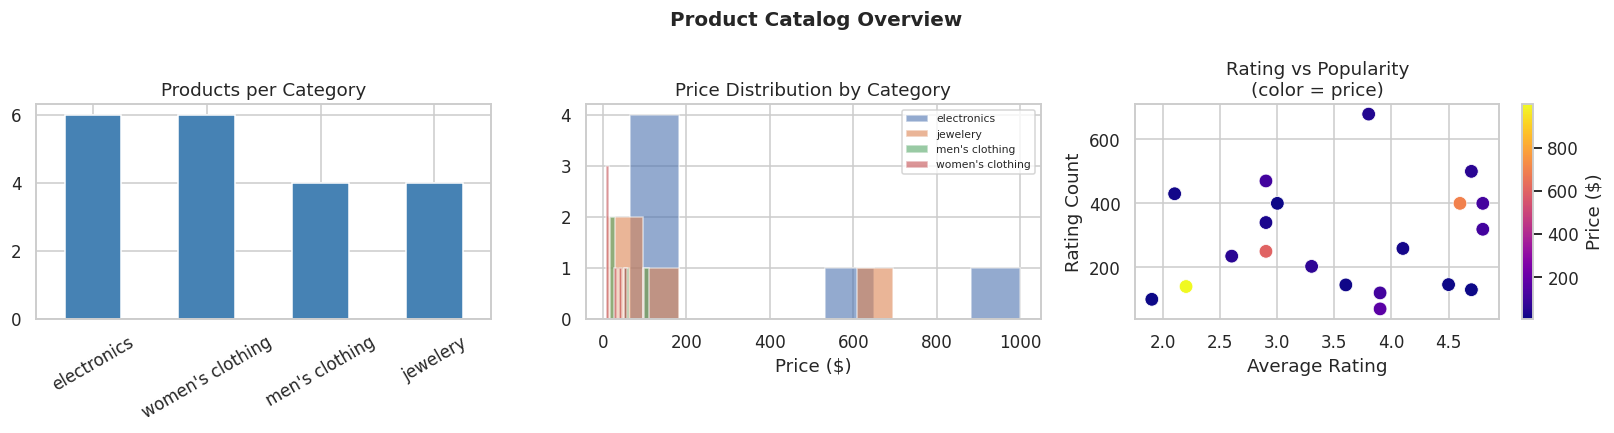

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Product Catalog Overview', fontsize=13, fontweight='bold')

# Category distribution
products['category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Products per Category')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Price distribution by category
for cat, grp in products.groupby('category'):
    axes[1].hist(grp['price'], bins=8, alpha=0.6, label=cat)
axes[1].set_title('Price Distribution by Category')
axes[1].set_xlabel('Price ($)')
axes[1].legend(fontsize=7)

# Rating vs popularity
sc = axes[2].scatter(products['rating'], products['rating_count'],
                     c=products['price'], cmap='plasma', s=80, edgecolors='w', linewidth=0.5)
plt.colorbar(sc, ax=axes[2], label='Price ($)')
axes[2].set_title('Rating vs Popularity\n(color = price)')
axes[2].set_xlabel('Average Rating')
axes[2].set_ylabel('Rating Count')

plt.tight_layout()
plt.show()

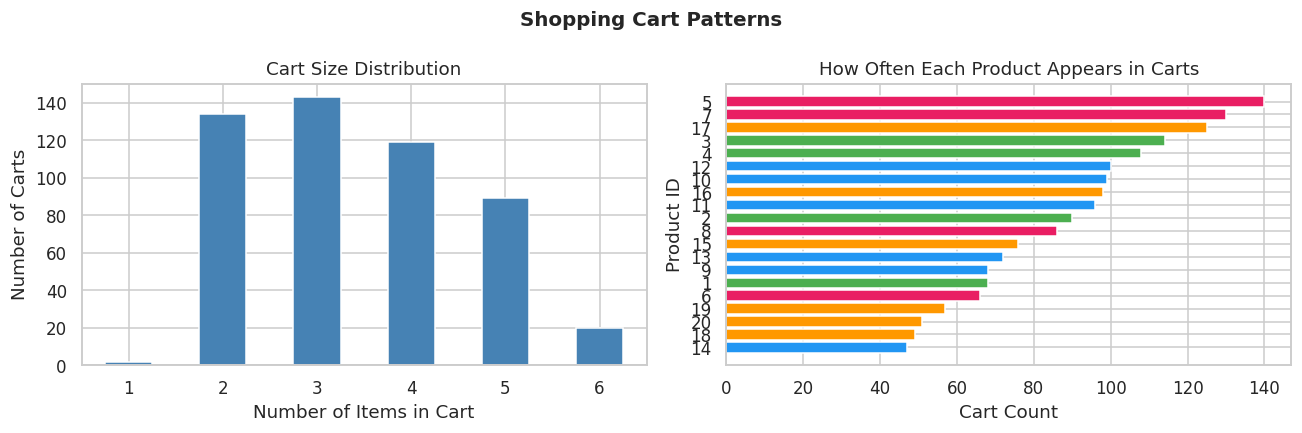

In [4]:
# Cart size distribution
cart_sizes = [len(c['products']) for c in carts_raw]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Shopping Cart Patterns', fontsize=13, fontweight='bold')

pd.Series(cart_sizes).value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Cart Size Distribution')
axes[0].set_xlabel('Number of Items in Cart')
axes[0].set_ylabel('Number of Carts')
axes[0].tick_params(axis='x', rotation=0)

# Product frequency (how many carts each product appears in)
freq = defaultdict(int)
for cart in carts_raw:
    for item in cart['products']:
        freq[item['productId']] += 1

freq_df = pd.DataFrame(freq.items(), columns=['product_id', 'cart_count'])\
            .merge(products[['id', 'category']], left_on='product_id', right_on='id')\
            .sort_values('cart_count', ascending=True)

axes[1].barh(freq_df['product_id'].astype(str), freq_df['cart_count'],
             color=freq_df['category'].map({
                 'electronics': '#2196F3', 'jewelery': '#E91E63',
                 "men's clothing": '#4CAF50', "women's clothing": '#FF9800'
             }))
axes[1].set_title('How Often Each Product Appears in Carts')
axes[1].set_xlabel('Cart Count')
axes[1].set_ylabel('Product ID')

plt.tight_layout()
plt.show()

---
## 2. Co-Purchase Heatmap

Which products are bought together most often? The heatmap below shows the co-occurrence matrix — darker cells = more frequent co-purchases.

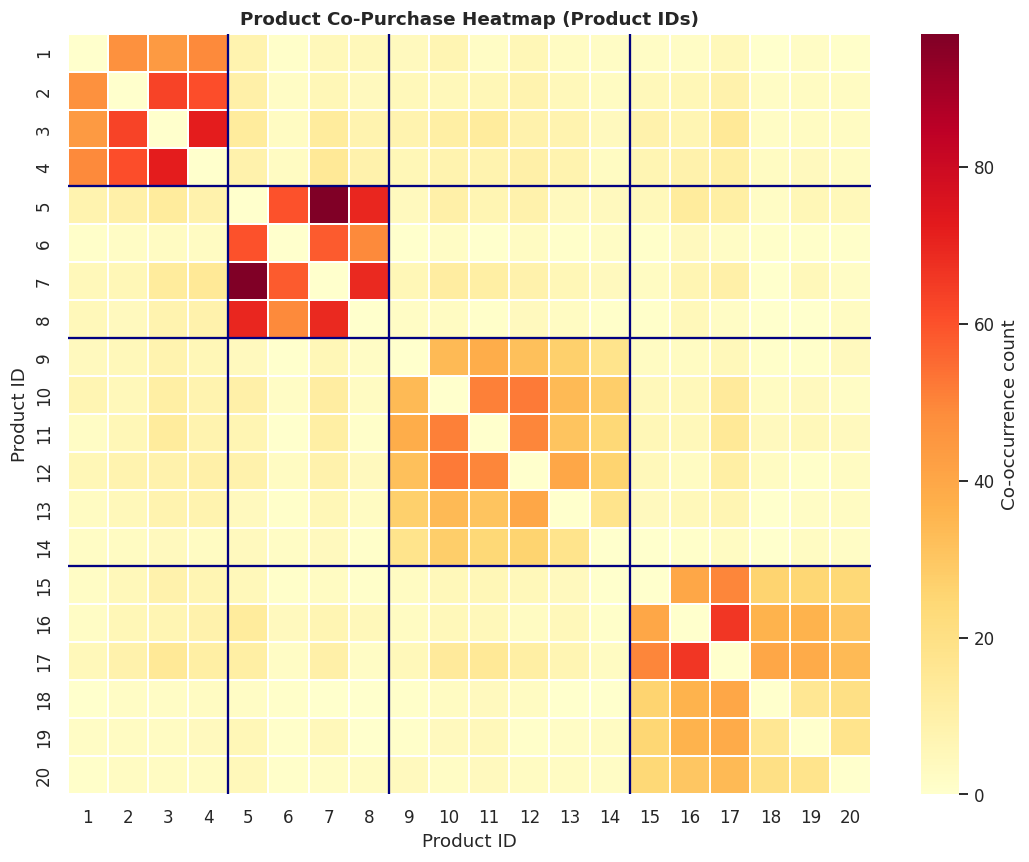

Products 1-4: men's clothing | 5-8: jewelery | 9-14: electronics | 15-20: women's clothing


In [5]:
co_occur = defaultdict(int)
for cart in carts_raw:
    ids = [p['productId'] for p in cart['products']]
    for i in range(len(ids)):
        for j in range(i+1, len(ids)):
            a, b = min(ids[i], ids[j]), max(ids[i], ids[j])
            co_occur[(a, b)] += 1

pid_list = sorted(products['id'].tolist())
co_matrix = pd.DataFrame(0, index=pid_list, columns=pid_list)
for (a, b), cnt in co_occur.items():
    co_matrix.loc[a, b] = cnt
    co_matrix.loc[b, a] = cnt

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(co_matrix, cmap='YlOrRd', linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Co-occurrence count'})
ax.set_title('Product Co-Purchase Heatmap (Product IDs)', fontsize=12, fontweight='bold')
ax.set_xlabel('Product ID')
ax.set_ylabel('Product ID')

# Annotate category boundaries
category_order = ["men's clothing", 'jewelery', 'electronics', "women's clothing"]
boundaries = [0]
for cat in category_order:
    count = (products['category'] == cat).sum()
    boundaries.append(boundaries[-1] + count)
for b in boundaries[1:-1]:
    ax.axhline(b, color='navy', linewidth=1.5)
    ax.axvline(b, color='navy', linewidth=1.5)

plt.tight_layout()
plt.show()
print('Products 1-4: men\'s clothing | 5-8: jewelery | 9-14: electronics | 15-20: women\'s clothing')

---
## 3. Feature Analysis

Each product pair is described by 11 engineered features. Let's look at how each feature differs between positive (co-purchased) and negative (not co-purchased) pairs.

In [6]:
X = pd.read_parquet(ROOT / 'X.parquet')
y = pd.read_csv(ROOT / 'y.csv').squeeze()

print(f'Feature matrix: {X.shape[0]:,} rows × {X.shape[1]} features')
print(f'Label balance : {y.value_counts().to_dict()}')
X.describe().round(2)

Feature matrix: 9,868 rows × 11 features
Label balance : {1: 4934, 0: 4934}


,price_diff,price_ratio,same_category,rating_diff,popularity_A,popularity_B,popularity_ratio,age_diff,co_occur_count,freq_A,freq_B
count,9868.00,9868.00,9868.00,9868.00,9868.00,9868.00,9868.00,9868.00,9868.00,9868.00,9868.00
mean,221.32,0.34,0.42,1.17,325.20,302.03,0.55,94.78,23.46,94.63,89.79
std,291.25,0.29,0.49,0.77,161.79,161.21,0.24,75.65,24.28,26.68,27.05
min,0.00,0.01,0.00,0.00,70.00,70.00,0.10,17.00,0.00,47.00,47.00
25%,24.00,0.10,0.00,0.60,203.00,145.00,0.34,34.00,5.00,72.00,68.00
50%,59.00,0.24,0.00,1.00,340.00,259.00,0.54,68.00,11.00,98.00,90.00
75%,490.00,0.53,1.00,1.80,430.00,400.00,0.74,153.00,40.00,114.00,108.00
max,992.04,1.00,1.00,2.90,679.00,679.00,1.00,323.00,97.00,140.00,140.00


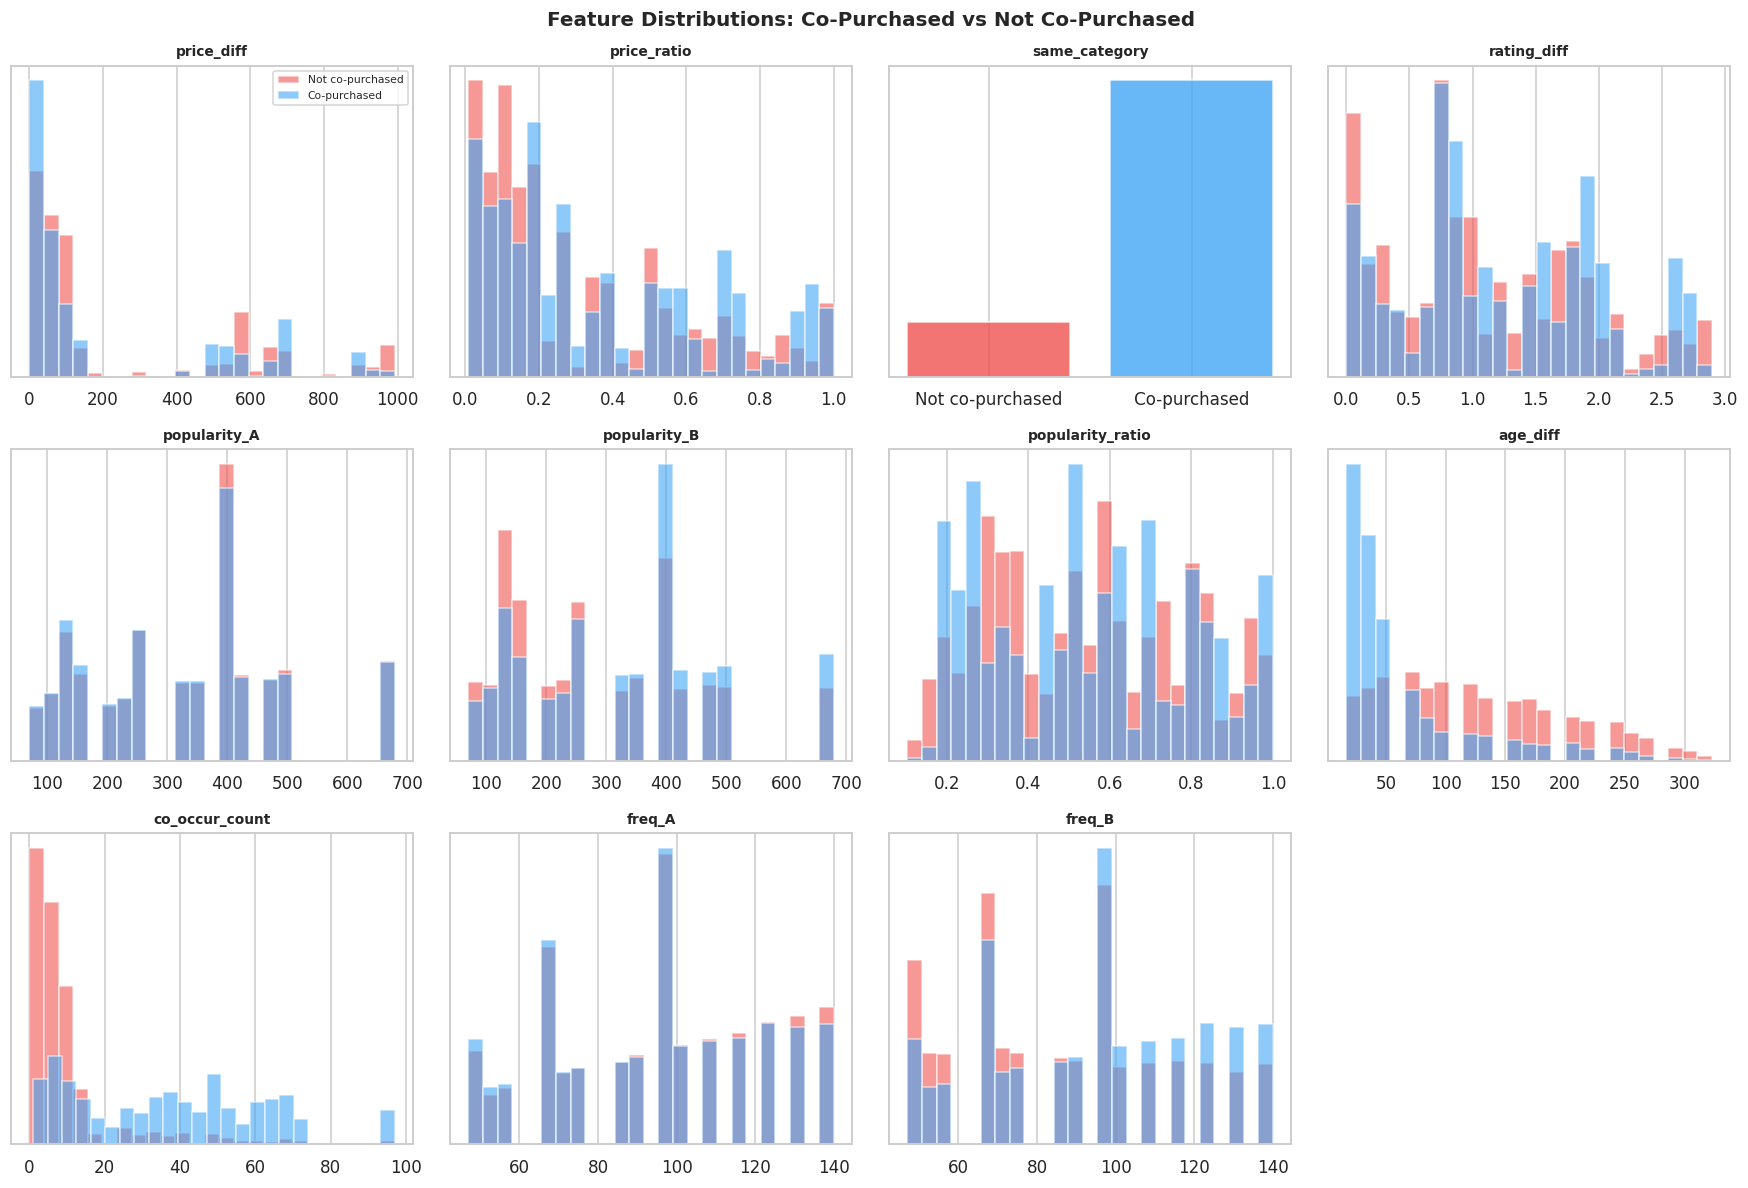

In [7]:
features = X.columns.tolist()
df = X.copy()
df['label'] = y.values

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle('Feature Distributions: Co-Purchased vs Not Co-Purchased', fontsize=13, fontweight='bold')
axes_flat = axes.flatten()

for i, feat in enumerate(features):
    ax = axes_flat[i]
    for lbl, color, name in [(0, '#EF5350', 'Not co-purchased'), (1, '#42A5F5', 'Co-purchased')]:
        subset = df.loc[df['label'] == lbl, feat]
        if feat in ('same_category',):  # binary feature
            ax.bar([name], [subset.mean()], color=color, alpha=0.8)
        else:
            ax.hist(subset, bins=25, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_yticks([])
    if i == 0:
        ax.legend(fontsize=7)

# Hide unused subplot
for j in range(len(features), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

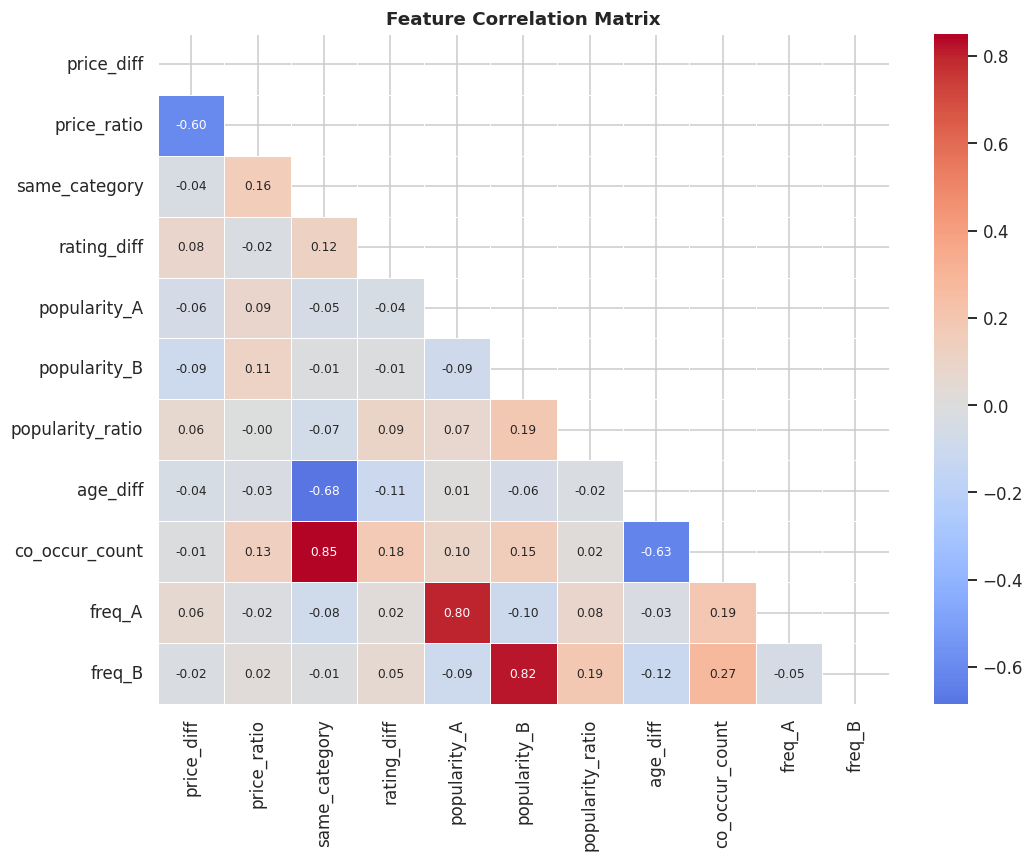

In [8]:
# Correlation matrix of features
fig, ax = plt.subplots(figsize=(10, 8))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Model Training & Evaluation

We train an XGBoost classifier. The model was already tuned via `RandomizedSearchCV` in `train_model.py` — here we load the best saved model and evaluate it in detail.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Load pre-tuned model
model = xgb.XGBClassifier()
model.load_model(MODELS / 'co_purchase_model.json')

probs = model.predict_proba(X_test)[:, 1]
preds = (probs >= 0.5).astype(int)

roc_auc = roc_auc_score(y_test, probs)
pr_auc  = average_precision_score(y_test, probs)
f1      = f1_score(y_test, preds)

print(f'Test-set results')
print(f'  ROC-AUC : {roc_auc:.4f}')
print(f'  PR-AUC  : {pr_auc:.4f}')
print(f'  F1 Score: {f1:.4f}')

Test-set results
  ROC-AUC : 0.8467
  PR-AUC  : 0.8509
  F1 Score: 0.7646


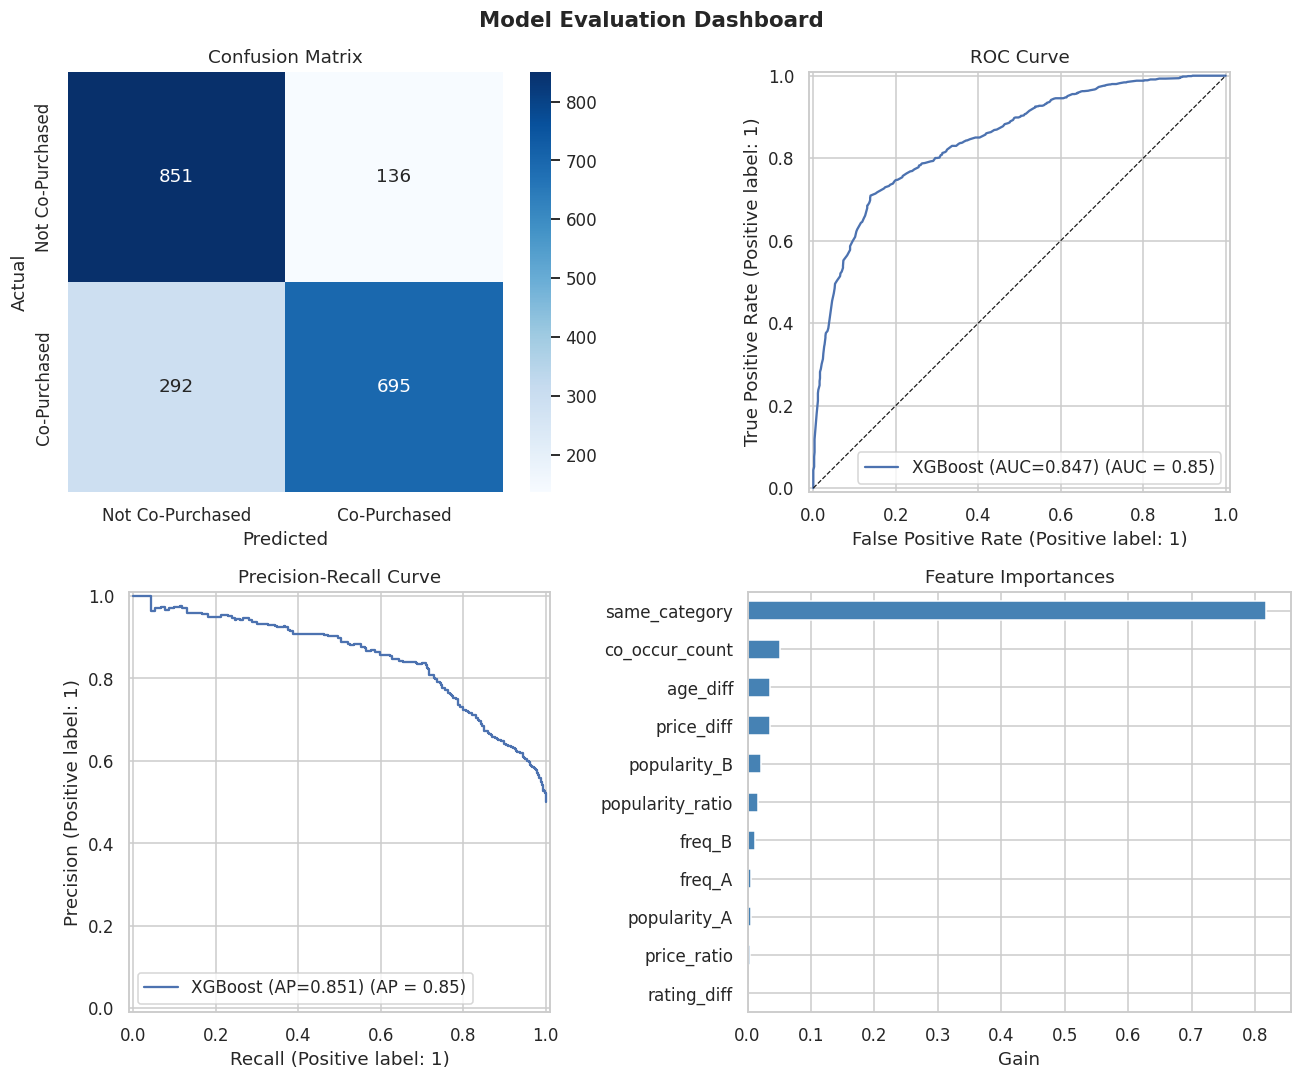

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Model Evaluation Dashboard', fontsize=14, fontweight='bold')

# Confusion matrix
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Co-Purchased', 'Co-Purchased'],
            yticklabels=['Not Co-Purchased', 'Co-Purchased'], ax=axes[0, 0])
axes[0, 0].set_title('Confusion Matrix')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# ROC curve
RocCurveDisplay.from_predictions(y_test, probs, ax=axes[0, 1],
                                  name=f'XGBoost (AUC={roc_auc:.3f})')
axes[0, 1].plot([0,1],[0,1],'k--', linewidth=0.8)
axes[0, 1].set_title('ROC Curve')

# PR curve
PrecisionRecallDisplay.from_predictions(y_test, probs, ax=axes[1, 0],
                                         name=f'XGBoost (AP={pr_auc:.3f})')
axes[1, 0].set_title('Precision-Recall Curve')

# Feature importance
imp = pd.Series(model.feature_importances_, index=X.columns).sort_values()
imp.plot(kind='barh', ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('Feature Importances')
axes[1, 1].set_xlabel('Gain')

plt.tight_layout()
plt.show()

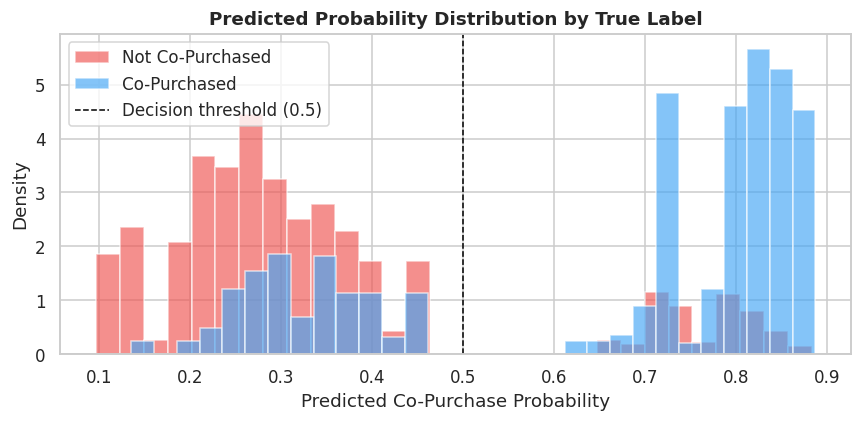

Good separation between classes indicates the model has learned meaningful signal.


In [11]:
# Probability distribution by true label
fig, ax = plt.subplots(figsize=(8, 4))
prob_df = pd.DataFrame({'prob': probs, 'label': y_test.values})
for lbl, color, name in [(0, '#EF5350', 'Not Co-Purchased'), (1, '#42A5F5', 'Co-Purchased')]:
    subset = prob_df.loc[prob_df['label'] == lbl, 'prob']
    ax.hist(subset, bins=30, alpha=0.65, color=color, label=name, density=True)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Decision threshold (0.5)')
ax.set_title('Predicted Probability Distribution by True Label', fontweight='bold')
ax.set_xlabel('Predicted Co-Purchase Probability')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()
print('Good separation between classes indicates the model has learned meaningful signal.')

---
## 5. Live Recommendations

Let's use the trained model to generate co-purchase recommendations — exactly what a production recommendation engine would do.

In [12]:
# Rebuild co-occurrence and frequency maps
co_occur_map = defaultdict(int)
freq_map     = defaultdict(int)
for cart in carts_raw:
    ids = [p['productId'] for p in cart['products']]
    for pid in ids:
        freq_map[pid] += 1
    for i in range(len(ids)):
        for j in range(i+1, len(ids)):
            a, b = min(ids[i], ids[j]), max(ids[i], ids[j])
            co_occur_map[(a, b)] += 1

products_idx = pd.json_normalize(products_raw).set_index('id')
products_idx.columns = [c.replace('.', '_') for c in products_idx.columns]
today = Timestamp('today')

def build_features(A, B):
    pa, pb = products_idx.loc[A], products_idx.loc[B]
    price_a, price_b = pa['price'], pb['price']
    pop_a,   pop_b   = pa['rating_count'], pb['rating_count']
    age_a = (today - pd.to_datetime(pa['release_date'])).days
    age_b = (today - pd.to_datetime(pb['release_date'])).days
    key   = (min(A, B), max(A, B))
    return {
        'price_diff'      : abs(price_a - price_b),
        'price_ratio'     : min(price_a, price_b) / max(price_a, price_b) if max(price_a, price_b) > 0 else 1.0,
        'same_category'   : int(pa['category'] == pb['category']),
        'rating_diff'     : abs(pa['rating_rate'] - pb['rating_rate']),
        'popularity_A'    : pop_a,
        'popularity_B'    : pop_b,
        'popularity_ratio': min(pop_a, pop_b) / max(pop_a, pop_b) if max(pop_a, pop_b) > 0 else 1.0,
        'age_diff'        : abs(age_a - age_b),
        'co_occur_count'  : co_occur_map.get(key, 0),
        'freq_A'          : freq_map.get(A, 0),
        'freq_B'          : freq_map.get(B, 0),
    }

def recommend(product_id, top_n=5):
    candidates = [pid for pid in products_idx.index if pid != product_id]
    rows  = [build_features(product_id, B) for B in candidates]
    X_cand = pd.DataFrame(rows)
    probs  = model.predict_proba(X_cand)[:, 1]
    return pd.DataFrame({
        'product_id': candidates,
        'title'     : [products_idx.loc[b, 'title'][:55] for b in candidates],
        'category'  : [products_idx.loc[b, 'category'] for b in candidates],
        'price'     : [products_idx.loc[b, 'price'] for b in candidates],
        'prob'      : probs,
    }).sort_values('prob', ascending=False).head(top_n).reset_index(drop=True)

print('Recommendation engine ready.')

Recommendation engine ready.


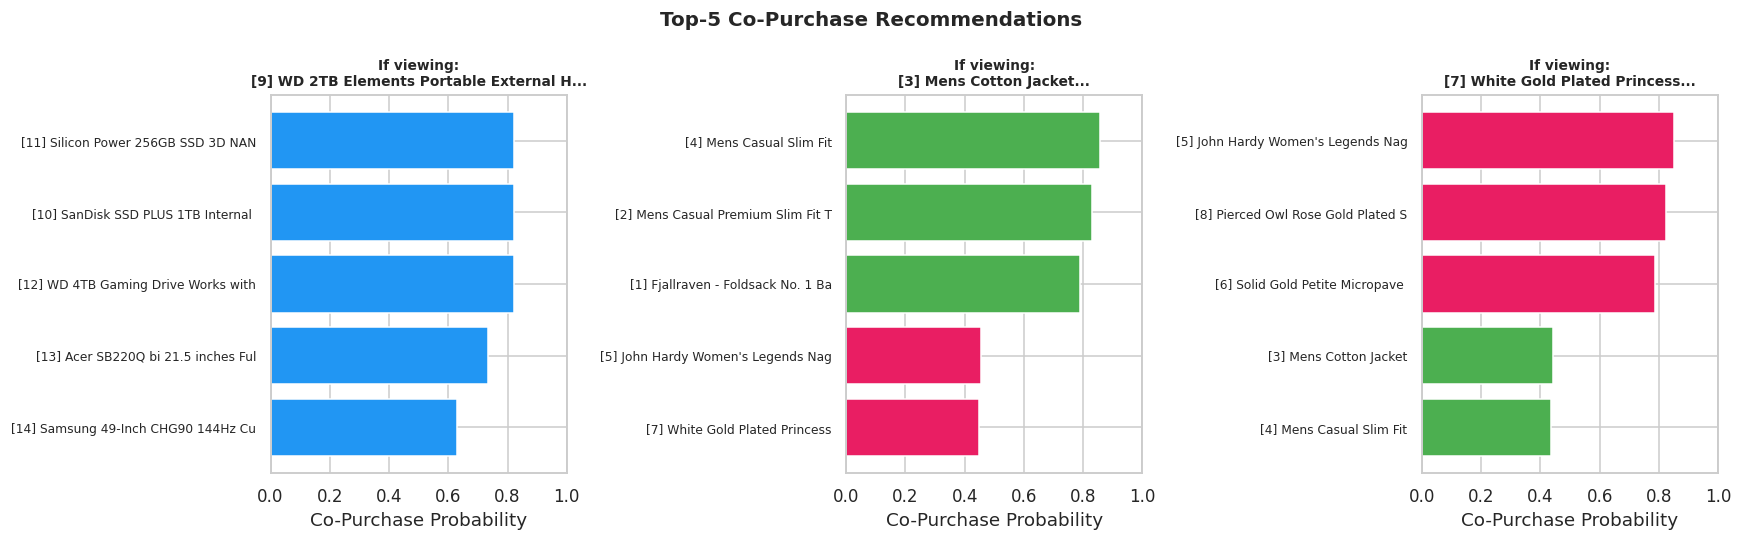

In [13]:
# Try recommendations for three different anchor products
anchor_ids = [9, 3, 7]   # Electronics, Men's Clothing, Jewelry

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Top-5 Co-Purchase Recommendations', fontsize=13, fontweight='bold')

category_colors = {
    'electronics': '#2196F3', 'jewelery': '#E91E63',
    "men's clothing": '#4CAF50', "women's clothing": '#FF9800'
}

for ax, pid in zip(axes, anchor_ids):
    anchor = products_idx.loc[pid]
    recs   = recommend(pid, top_n=5)
    colors = [category_colors.get(c, 'gray') for c in recs['category']]
    bars   = ax.barh(range(len(recs)), recs['prob'], color=colors, edgecolor='white')
    ax.set_yticks(range(len(recs)))
    ax.set_yticklabels([f"[{r.product_id}] {r.title[:30]}" for r in recs.itertuples()], fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Co-Purchase Probability')
    ax.set_title(f"If viewing:\n[{pid}] {anchor['title'][:35]}...", fontsize=9, fontweight='bold')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [14]:
# Full recommendation table for product 9
print('Anchor: WD 2TB Elements Portable External Hard Drive (Product #9)')
print('Category: electronics | Price: $64.00')
print()
recs = recommend(9, top_n=10)
recs.index += 1
recs.columns = ['Product ID', 'Title', 'Category', 'Price ($)', 'Co-Purchase Prob']
recs['Co-Purchase Prob'] = recs['Co-Purchase Prob'].round(3)
print(recs.to_string())

Anchor: WD 2TB Elements Portable External Hard Drive (Product #9)
Category: electronics | Price: $64.00

    Product ID                                                    Title          Category  Price ($)  Co-Purchase Prob
1           11  Silicon Power 256GB SSD 3D NAND A55 SLC Cache Performan       electronics     109.00             0.821
2           10      SanDisk SSD PLUS 1TB Internal SSD - SATA III 6 Gb/s       electronics     109.00             0.821
3           12  WD 4TB Gaming Drive Works with Playstation 4 Portable E       electronics     114.00             0.821
4           13  Acer SB220Q bi 21.5 inches Full HD (1920 x 1080) IPS Ul       electronics     599.00             0.733
5           14  Samsung 49-Inch CHG90 144Hz Curved Gaming Monitor (LC49       electronics     999.99             0.629
6            3                                       Mens Cotton Jacket    men's clothing      55.99             0.369
7            7                               White Gold Plated

---
## Summary

| Step | Detail |
|------|--------|
| **Data** | 20 products, 507 carts (7 real + 500 synthetic), 9,868 labeled pairs |
| **Features** | 11 per pair — price, category, rating, popularity, age, co-occurrence |
| **Model** | XGBoost, tuned via 50-iteration RandomizedSearchCV |
| **ROC-AUC** | **0.847** (test) / 0.825 ± 0.008 (5-fold CV) |
| **PR-AUC** | **0.851** (test) |
| **Strongest feature** | `co_occur_count` — historical co-purchase frequency |

### Key Takeaways
- Category membership is a strong prior for co-purchase likelihood
- `co_occur_count` alone is highly predictive, but price and popularity features add meaningful signal
- The model generalizes well: consistent CV scores with low variance confirm the pipeline isn't overfitting
- The recommendation engine produces sensible results — electronics are recommended alongside other electronics